In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df_demand=pd.read_csv(r'Demand_forecasting.csv')

In [8]:
df_demand.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [9]:
df_demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   str    
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   str    
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   str    
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   str    
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   str    
 9   Outlet_Location_Type       5681 non-null   str    
 10  Outlet_Type                5681 non-null   str    
dtypes: float64(3), int64(1), str(7)
memory usage: 795.9 KB


In [6]:
df_demand.isna().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [10]:
df_demand.isna().sum()/df_demand.shape[0]

Item_Identifier              0.000000
Item_Weight                  0.171801
Item_Fat_Content             0.000000
Item_Visibility              0.000000
Item_Type                    0.000000
Item_MRP                     0.000000
Outlet_Identifier            0.000000
Outlet_Establishment_Year    0.000000
Outlet_Size                  0.282697
Outlet_Location_Type         0.000000
Outlet_Type                  0.000000
dtype: float64

In [11]:
df_demand.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4705.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.664849,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,8.645000,0.027047,94.412000,1987.000000
50%,12.500000,0.054154,141.415400,1999.000000
75%,16.700000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


In [36]:
df_demand[df_demand["Outlet_Size"].isna()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
8,FDN33,6.305,Regular,0.123365,Snack Foods,95.7436,OUT045,2002,NaN,Tier 2,Supermarket Type1
9,FDA36,5.985,Low Fat,0.005698,Baking Goods,186.8924,OUT017,2007,NaN,Tier 2,Supermarket Type1
...,...,...,...,...,...,...,...,...,...,...,...
5668,FDC44,15.600,Low Fat,0.288892,Fruits and Vegetables,115.1518,OUT010,1998,NaN,Tier 3,Grocery Store
5670,FDO03,10.395,Regular,0.037092,Meat,229.4352,OUT017,2007,NaN,Tier 2,Supermarket Type1
5678,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,NaN,Tier 2,Supermarket Type1
5679,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,NaN,Tier 2,Supermarket Type1


In [12]:
df_demand.isna().sum().sort_values(ascending=False)

Outlet_Size                  1606
Item_Weight                   976
Item_Identifier                 0
Item_Fat_Content                0
Item_Visibility                 0
Item_MRP                        0
Item_Type                       0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [13]:
df_demand.duplicated().sum()

np.int64(0)

In [14]:
df_demand.Outlet_Size.unique()

<ArrowStringArray>
['Medium', nan, 'Small', 'High']
Length: 4, dtype: str

In [15]:
df_demand.Item_Fat_Content.unique()

<ArrowStringArray>
['Low Fat', 'reg', 'Regular', 'LF', 'low fat']
Length: 5, dtype: str

In [12]:
df_demand.Item_Fat_Content=df_demand.Item_Fat_Content.str.upper()

In [16]:
df_demand.Item_Fat_Content.sample(5)

3940    Low Fat
1138    Low Fat
3856    Low Fat
1006    Low Fat
3792    Low Fat
Name: Item_Fat_Content, dtype: str

In [17]:
df_demand.Item_Fat_Content=df_demand.Item_Fat_Content.str.replace({"REG":"REGULAR","LF":"LOW FAT"})

In [18]:
df_demand.Item_Fat_Content.tail()
df_demand.Item_Fat_Content.unique()

<ArrowStringArray>
['Low Fat', 'reg', 'Regular', 'LOW FAT', 'low fat']
Length: 5, dtype: str

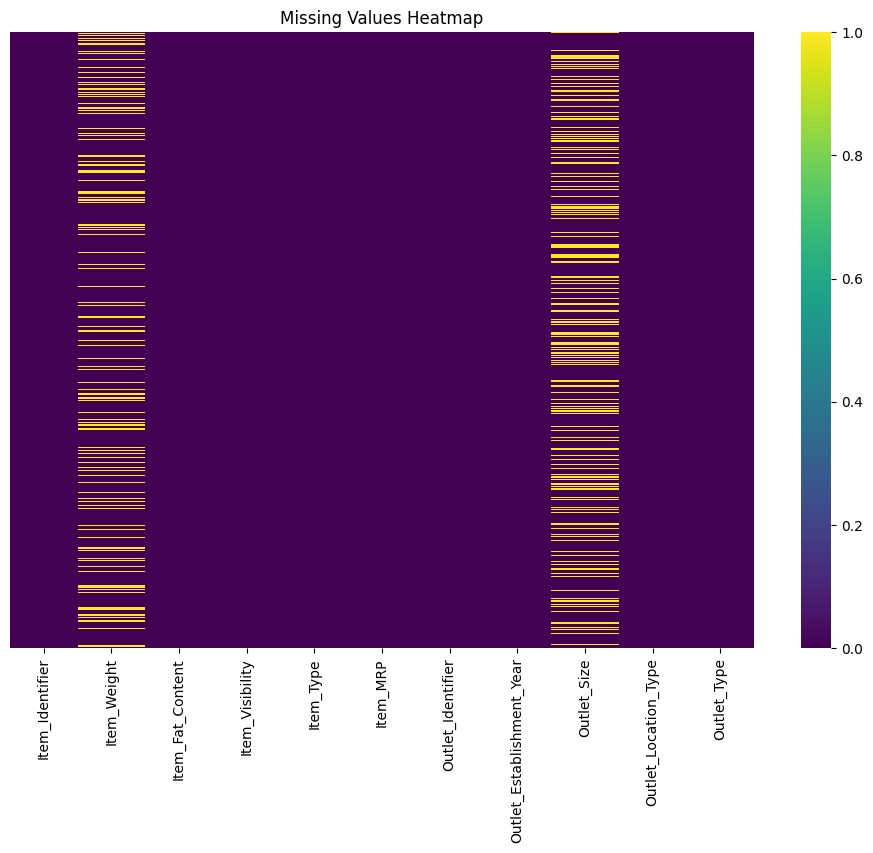

In [19]:
# Heatmap of missing values
plt.figure(figsize=(12, 8))
sns.heatmap(df_demand.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


In [20]:
# Check for missing item weights
item_weight_missing = df_demand['Item_Weight'].isnull().sum()
print(f"Missing Item_Weight values: {item_weight_missing}")

# Analyze missing weights by item type
if item_weight_missing > 0:
    missing_weight_analysis = df_demand[df_demand['Item_Weight'].isnull()]['Item_Type'].value_counts()
    print("Missing weights by Item Type:")
    print(missing_weight_analysis)


Missing Item_Weight values: 976
Missing weights by Item Type:
Item_Type
Fruits and Vegetables    133
Snack Foods              124
Frozen Foods             113
Household                112
Dairy                     79
Canned                    76
Baking Goods              74
Health and Hygiene        58
Soft Drinks               52
Meat                      41
Hard Drinks               28
Breads                    26
Starchy Foods             24
Others                    20
Breakfast                 13
Seafood                    3
Name: count, dtype: int64


In [62]:
# Check outlet size missing values
outlet_size_missing = df_demand['Outlet_Size'].isnull().sum()
print(f"Missing Outlet_Size values: {outlet_size_missing}")

# If there are missing outlet sizes, analyze by outlet type
if outlet_size_missing > 0:
    missing_size_analysis = df_demand[df_demand['Outlet_Size'].isnull()]['Outlet_Type'].value_counts()
    print("Missing outlet sizes by Outlet Type:")
    print(missing_size_analysis)


Missing Outlet_Size values: 1606
Missing outlet sizes by Outlet Type:
Outlet_Type
Supermarket Type1    1236
Grocery Store         370
Name: count, dtype: int64


In [21]:
df_demand['Item_Visibility'] = df_demand['Item_Visibility'].replace(0, np.nan)
visibility_mean = df_demand.groupby('Item_Identifier')['Item_Visibility'].transform('mean')
df_demand['Item_Visibility'] = df_demand['Item_Visibility'].fillna(visibility_mean)
df_demand.isna().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                13
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64